# eq_SST_sea_cycle: Zonal structure of the amplitude of the mean seasonal cycle of SST in the equatorial Pacific

Computes the zonal root mean square error (RMSE) of of equatorial Pacific (150°E-90°W) amplitude (standard deviation) of the mean annual cycle (zonal 5°S-5°N average) sea surface temperature (SST) between model and observations (the time averaging creates a 12 months mean annual cycle time series from which the standard deviation is computed)

## Observations and reanalysis datasets used for comparison

The following reference observational datasets are used to evaluate the model simulations:

- **TropFlux (1979-2018)**: The primary dataset for comparison. TropFlux provides estimates of surface fluxes, including heat, momentum, and freshwater exchanges over the tropical oceans, specifically designed for tropical climate studies, and integrates satellite and in-situ observations.

Additional observational datasets used for comparison include:
- **20CRv2 (1871-2012)**: The 20th Century Reanalysis provides global atmospheric data based on surface pressure observations and ensemble assimilation techniques, reconstructing weather patterns over the past 140 years.
- **ERA-Interim (1979-2018)**: Reanalysis data produced by the European Centre for Medium-Range Weather Forecasts (ECMWF), offering high-resolution atmospheric and surface variables using a global assimilation model.
- **ERSSTv5 (1854-2018)**: The Extended Reconstructed Sea Surface Temperature dataset provides monthly global sea surface temperature anomalies based on historical in-situ and satellite observations, widely used in ocean and climate studies.
- **HadISST (1870-2018)**: The Hadley Centre Sea Ice and Sea Surface Temperature dataset offers global monthly SST and sea ice concentration fields, incorporating in-situ and satellite data for climate variability analysis.
- **NCEP2 (1979-2018)**: The second version of the NCEP reanalysis provides a range of atmospheric variables, including surface and upper-air data, and corrects issues in the original dataset, making it suitable for long-term climate and weather assessments.

## Dask Cluster 

Start a cluster with multiple cores 

In [ ]:
from dask.distributed import Client, progress
client = Client()
client

In [ ]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
esm_file = "/scratch/p66/fc6164/SeptSpinupA/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-088912.nc"

mylabel = "SeptSpinUpA"
startyear=610
endyear=790
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM path: ",esm_file)
print("Plot folder path: ",plotfolder)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=67, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34365 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34365/status,
Dashboard: /proxy/34365/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35079,Workers: 0
Dashboard: /proxy/34365/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33171,Total threads: 4
Dashboard: /proxy/38723/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:34563,


## Datasets

In [2]:
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:639: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, rem

In [3]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
),
## Note: It is possible to use tos (sea_surface_temperature; degC; ocean; mon) 
# "ACCESS-ESM1-5": 
#     Dataset(
#     short_name='tos',
#     project='CMIP6',
#     mip="Omon",
#     exp="historical",
#     ensemble="r1i1p1f1",
#     timerange="18500101/20190101",
#     dataset="ACCESS-ESM1-5",
#     grid="gn"
# )
}

obs_datasets = {
"HadISST": 
    Dataset(
    short_name='ts',
    dataset='HadISST',
    mip="Amon",
    project='OBS',
    type='reanaly',
    tier=2),
# "ERSSTv5":
#     Dataset(
#     short_name='tos',
#     dataset='NOAA-ERSSTv5',
#     mip="Omon",
#     project='OBS6',
#     type='reanaly',
#     tier=2),
# "ERA-Interim": 
#     Dataset(
#     short_name='tos',
#     dataset='ERA-Interim',
#     mip="Omon",
#     project='OBS6',
#     type='reanaly',
#     timerange="19790101/20190101",
#     tier=3)
}

## Add Ancillary files

In [4]:
for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [5]:
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_valid

In [6]:
import iris
from iris.util import equalise_attributes

esm16cube = iris.load_cube(esm_file,'surface_temperature')
#equalise_attributes(esm16cube)

esm16cube_concat = esm16cube#.concatenate()


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'ts'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'ts'
  warnings.warn(


In [7]:
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import monthly_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import axis_statistics
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import mask_landsea
import iris

In [8]:
def preproc1(cube):
    nino3_ep_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = climate_statistics(cube, operator='mean', period='monthly')
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed(['month_number'], iris.analysis.STD_DEV)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_ep_region)    
    cube = axis_statistics(cube, operator="mean", axis="y")
    return cube


def preproc2(cube):
    nino3_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = climate_statistics(cube, operator='mean', period='monthly')
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed(['month_number'], iris.analysis.STD_DEV)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    return cube


def preproc1_pi(cube, start, end):
    nino3_ep_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = climate_statistics(cube, operator='mean', period='monthly')
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed(['month_number'], iris.analysis.STD_DEV)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_ep_region)    
    cube = axis_statistics(cube, operator="mean", axis="y")
    return cube

def preproc2_pi(cube, start, end):
    nino3_latext_region = {"start_longitude": 140., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = climate_statistics(cube, operator='mean', period='monthly')
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed(['month_number'], iris.analysis.STD_DEV)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    return cube


In [9]:
model_ctrldatasets_prep1 = {name: preproc1_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
#model_datasets_prep1 = preproc1_pi(esm16cube_concat[0],1800,2000)
model_datasets_prep1 = preproc1_pi(esm16cube,startyear,endyear) 
obs_datasets_prep1 = {name: preproc1(dataset) for name, dataset in obs_datasets.items()}

model_ctrldatasets_prep2 = {name: preproc2_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep2 = preproc2_pi(esm16cube,startyear,endyear) 
obs_datasets_prep2 = {name: preproc2(dataset) for name, dataset in obs_datasets.items()}

# Diagnostics Level 1


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


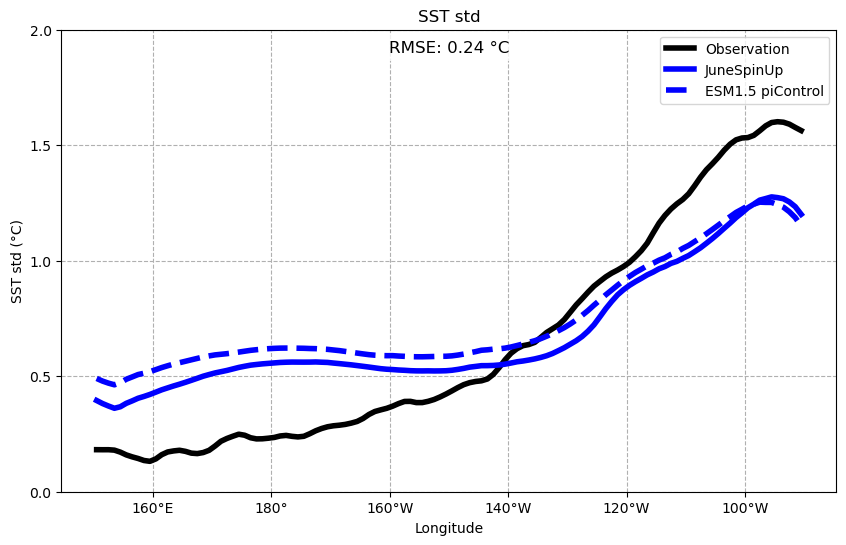

In [10]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import numpy as np

# Function to format x-axis labels with degree symbols and N/S
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

plt.figure(figsize=(10, 6))


obs_data = obs_datasets_prep1["HadISST"]
model_ctrldata = model_ctrldatasets_prep1["ACCESS-ESM1-5"]
model_data = model_datasets_prep1#["ACCESS-ESM1-5"]

# Plot observation data in black
qplt.plot(obs_data, color='black', label='Observation', linewidth=4)

# Plot model data in blue
qplt.plot(model_data, color='blue', label=mylabel, linewidth=4)
qplt.plot(model_ctrldata, color='blue', label='ESM1.5 piControl', linewidth=4,linestyle='--')

rmse = np.sqrt(np.mean((obs_data.data - model_data.data) ** 2))

# Adding labels and title
plt.xlabel('Longitude')
plt.ylabel('SST std (°C)')
plt.title('SST std')
plt.grid(linestyle='--')
plt.yticks(np.arange(0,2.5, step=0.5))

# Adding RMSE text on top of the plot
plt.text(0.5, 0.95, f'RMSE: {rmse:.2f} °C', fontsize=12, ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Setting custom x-axis formatter
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))

# Adding a legend
plt.legend()

# Display the plot
plt.show()

Figure 1: Zonal bias in the amplitude of the mean seasonal cycle of sea surface temperature (SST) in the equatorial Pacific (averaged between 5°S–5°N). The black curve represents the reference data, while the blue curve represents the model data. The metric displayed is the zonal RMSE between the model and reference curves.

# Diagnostics Level 2


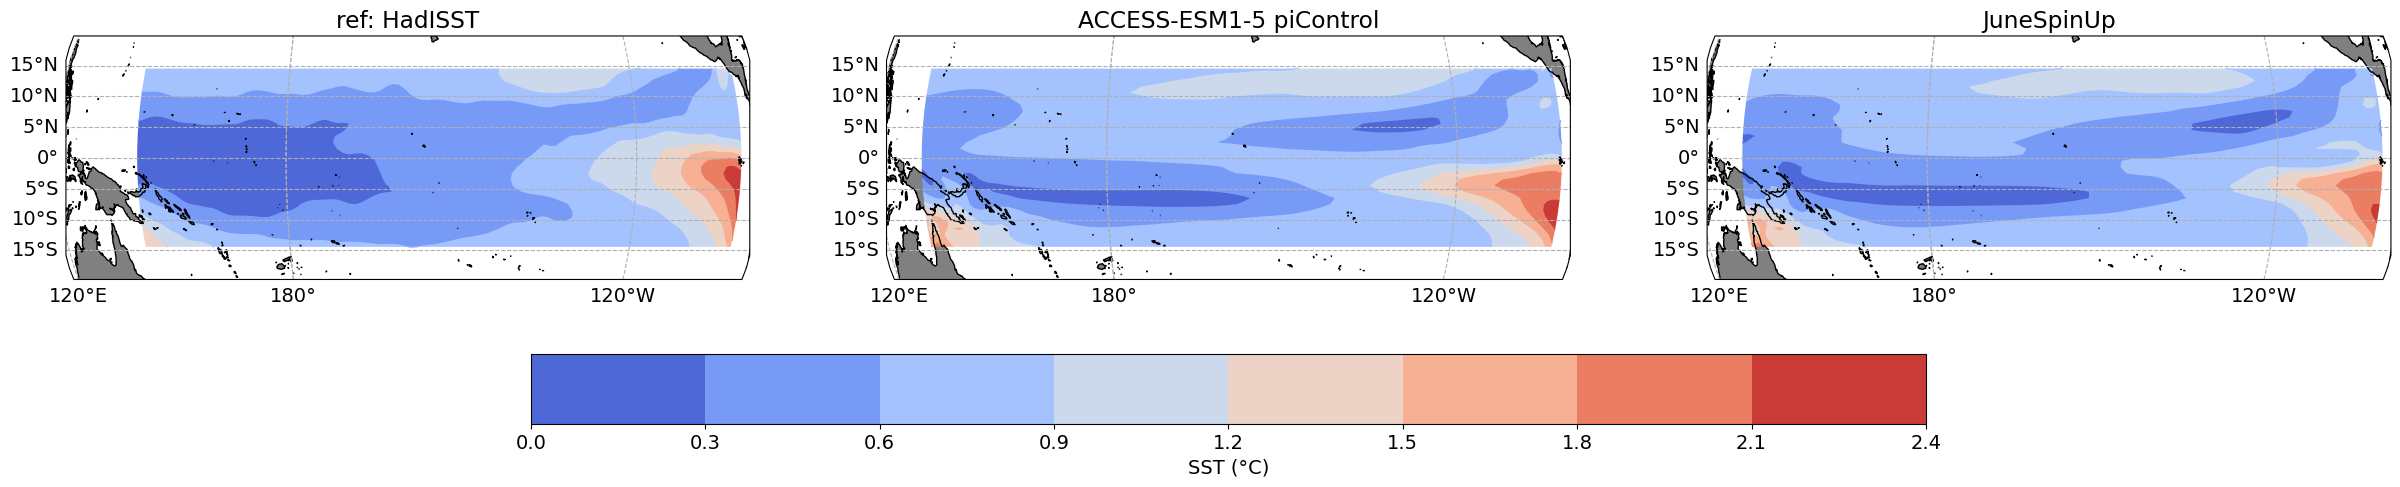

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Importing numpy for linear space creation
import numpy as np

import iris
import iris.plot as iplt

obs_data = obs_datasets_prep2["HadISST"]
model_ctrldata = model_ctrldatasets_prep2["ACCESS-ESM1-5"]
model_data = model_datasets_prep2#["ACCESS-ESM1-5"]
plt.rcParams.update({'font.size': 14})


# Use the coolwarm colormap
cmap = plt.get_cmap('coolwarm')

# Create a large figure
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width

# Center the map on the Pacific Ocean (roughly around 180° longitude)
proj = ccrs.Orthographic(central_longitude=-160, central_latitude=0)

# Define the normalization for the color scale with range of 20 to 33°C
norm = mcolors.Normalize()
plt.rcParams.update({'font.size': 14})

# Plot #1: contourf with axes longitude from -180 to 180
ax1 = plt.subplot(131, projection=proj)
cf1 = iplt.contourf(obs_data, cmap=cmap, norm=norm)
ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax1.coastlines()
ax1.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax1.set_title("ref: HadISST")

# Add gridlines for latitude and longitude
gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

# Plot #2: contourf with axes longitude from 0 to 360
ax2 = plt.subplot(132, projection=proj)
cf2 = iplt.contourf(model_ctrldata, cmap=cmap, norm=norm)
ax2.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax2.coastlines()
ax2.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax2.set_title("ACCESS-ESM1-5 piControl")

# Add gridlines for latitude and longitude
gl2 = ax2.gridlines(draw_labels=True, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False

# Plot #3: contourf with axes longitude from 0 to 360
ax3 = plt.subplot(133, projection=proj)
cf3 = iplt.contourf(model_data, cmap=cmap, norm=norm)
ax3.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax3.coastlines()
ax3.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax3.set_title(mylabel)

# Add gridlines for latitude and longitude
gl3 = ax3.gridlines(draw_labels=True, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False

# Add a single colorbar at the bottom
cbar = fig.colorbar(cf2, ax=[ax1, ax2,ax3], orientation='horizontal', pad=0.15, shrink=0.6)
cbar.set_label('SST (°C)')
#cbar.set_ticks(np.arange(20, 33))  # Set ticks at intervals of 2 degrees

plt.subplots_adjust(bottom=0.3)  # Further adjust bottom margin to fit the colorbar
plt.show()


Figure 2: Bias in the amplitude of the mean seasonal cycle of sea surface temperature (SST) in the equatorial Pacific. The left map represents the reference data, while the right map shows the model data.

# Diagnostic Level 3

The third level shows the zonal structure of the mean seasonal cycle in a Hovmöller diagram

In [17]:
from esmvalcore.preprocessor import axis_statistics


def preproc3(cube):
    eq_region = {"start_longitude": 160., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="monthly")
    cube = extract_region(cube, **eq_region)
    cube = axis_statistics(cube, axis="y", operator='mean')
    return cube

def preproc3_pi(cube,start,end):
    eq_region = {"start_longitude": 160., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="monthly")
    cube = extract_region(cube, **eq_region)
    cube = axis_statistics(cube, axis="y", operator='mean')
    return cube

model_ctrldatasets_prep3 = {name: preproc3_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep3 = preproc3_pi(esm16cube,startyear,endyear) 
obs_datasets_prep3 = {name: preproc3(dataset) for name, dataset in obs_datasets.items()}
process = {**obs_datasets_prep3,**model_ctrldatasets_prep3,mylabel:model_datasets_prep3}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


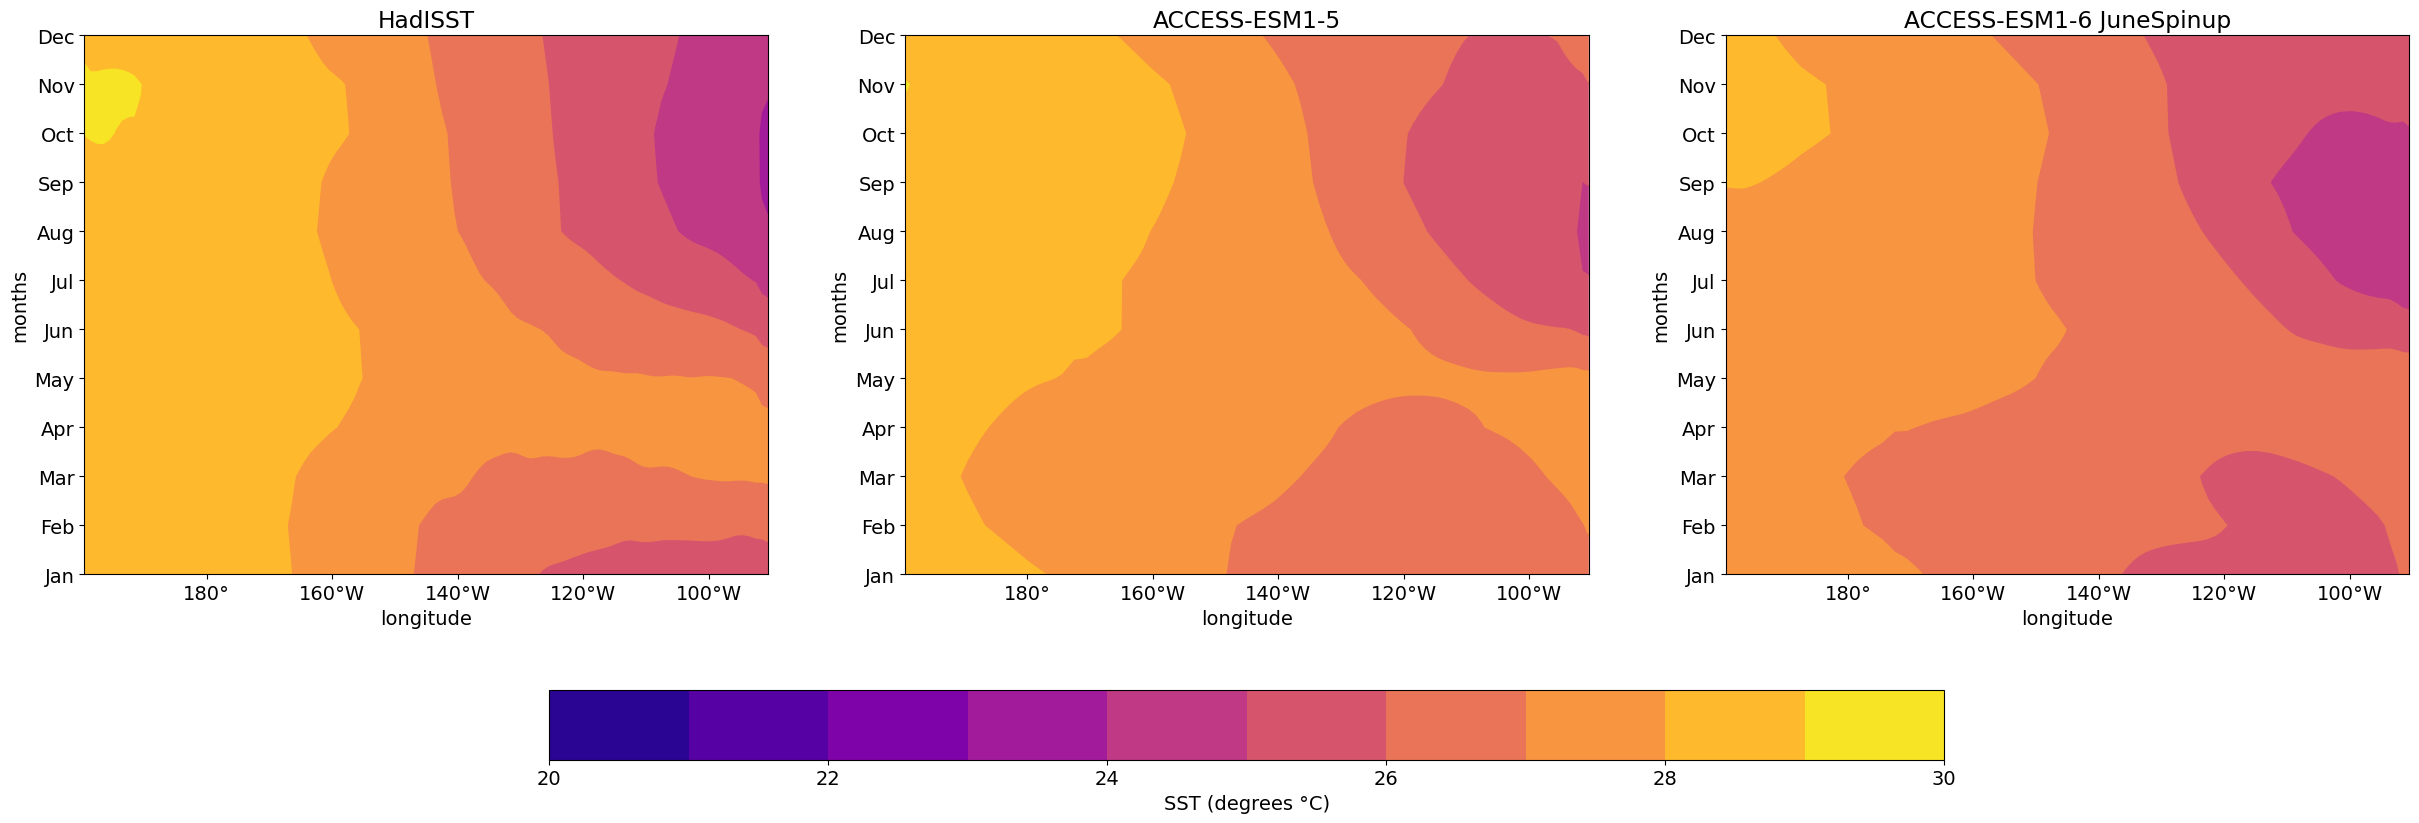

In [19]:
fig = plt.figure(figsize=(30, 10))
i=131
plt.rcParams.update({'font.size': 14})

# Define tick positions and labels for the y-axis (months)
month_ticks = np.arange(1, 13, 1)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axls =[]
for label, cube in process.items():
    
    ax1 = plt.subplot(i)
    cf1 = iplt.contourf(cube,coords=['longitude','month_number'],levels=np.arange(20,31,1),cmap="plasma")
    ax1.set_ylim(1, 12)
    ax1.set_yticks(ticks=month_ticks, labels=month_labels)
    ax1.set_title(label)
    ax1.set_ylabel("months")
    ax1.set_xlabel("longitude")
    axls.append(ax1)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))
    i+=1

# Add a single colorbar at the bottom
cbar = fig.colorbar(cf1, ax=axls, orientation='horizontal',shrink=0.6, extend='both')
cbar.set_label('SST (degrees °C)')
plt.show()

Figure 3: zonal structure of the mean seasonal cycle of sea surface temperature (SST) in the equatorial Pacific (5°S-5°N averaged). The left and right maps show respectively the reference and the model